# Thesis Results Analysis

This notebook analyzes processed questionnaire and task-performance data from a controlled user study comparing **2D Label** and **3D Ghost** situated visualization conditions in a VR-simulated AR industrial training task.

The public version of this notebook uses the processed datasets already included in the repository:

- `data_long_format.csv` — long-format dataset used for plotting and summary statistics
- `data_short_format.csv` — wide-format dataset, one row per participant and condition

The original raw questionnaire CSV files are not required to run this notebook.

## 1. Import Libraries

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Processed Data

The original raw CSV files (`CompletionTime.csv`, `Nasa.csv`, `SSQ.csv`, and `SUS.csv`) are not used in this public notebook.  
Instead, the notebook starts from the processed anonymized datasets so it can run directly from the files included in the GitHub repository.

In [9]:
# Load processed datasets
# data_long_format.csv is used for plotting and summary statistics.
# data_short_format.csv is kept as the merged wide-format dataset.

data = pd.read_csv("data_long_format.csv")
data_short = pd.read_csv("data_short_format.csv")

print("Long-format data shape:", data.shape)
print("Wide-format data shape:", data_short.shape)

data.head()

Long-format data shape: (1344, 4)
Wide-format data shape: (24, 58)


,Scene,Participant,variable,value
0,2D Label,P01,Completion Time,99.09
1,2D Label,P02,Completion Time,137.66
2,2D Label,P03,Completion Time,101.41
3,2D Label,P04,Completion Time,112.35
4,2D Label,P05,Completion Time,166.27


## 3. Summary Statistics

This table summarizes the main study metrics by visualization condition. It is useful for reporting the key findings in the README.

In [10]:
# Main metrics used in the result figures
metrics = [
    "Completion Time",
    "SUS Score",
    "NASA-TLX Score",
    "Nausea",
    "Oculomotor",
    "Disorientation",
    "SSQ Score"
]

summary_statistics = (
    data[data["variable"].isin(metrics)]
    .groupby(["variable", "Scene"])["value"]
    .agg(["mean", "median", "std", "min", "max", "count"])
    .round(2)
    .reset_index()
)

summary_statistics

,variable,Scene,mean,median,std,min,max,count
0,Completion Time,2D Label,151.05,151.96,45.11,99.09,230.42,12
1,Completion Time,3D Ghost,138.43,121.72,46.11,84.12,212.37,12
2,Disorientation,2D Label,30.16,27.84,28.98,0.00,69.60,12
3,Disorientation,3D Ghost,18.56,20.88,19.08,0.00,55.68,12
4,NASA-TLX Score,2D Label,3.78,3.50,0.89,2.83,5.67,12
5,NASA-TLX Score,3D Ghost,3.61,3.42,0.63,2.83,5.00,12
6,Nausea,2D Label,12.72,9.54,14.29,0.00,47.70,12
7,Nausea,3D Ghost,5.56,0.00,7.56,0.00,19.08,12
8,Oculomotor,2D Label,22.74,22.74,17.70,0.00,53.06,12
9,Oculomotor,3D Ghost,12.63,11.37,14.93,0.00,53.06,12


In [11]:
# Optional: save the summary table for reuse
summary_statistics.to_csv("summary_statistics.csv", index=False)

## 4. Visualizations

The following boxplots compare the two study conditions across task performance, usability, workload, and discomfort metrics.

In [12]:
COLNAME_INDEP_VAR = "Scene"

COLS_SUBPLOTS = {
    "Task Completion Time (s)": ["Completion Time"],
    "Usability": ["SUS Score"],
    "Workload": ["NASA-TLX Score"]
}

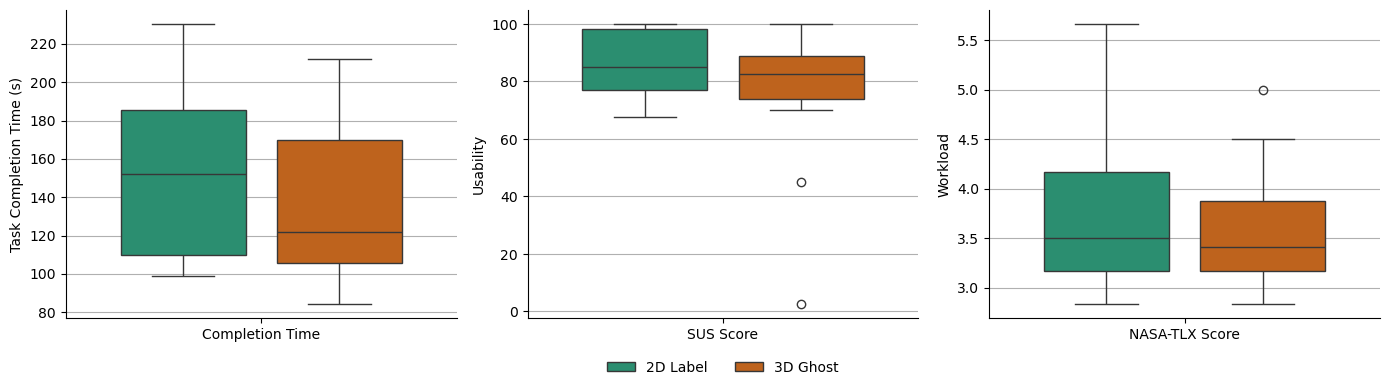

In [13]:
# Main results: task completion time, usability, and workload

f, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.reshape(-1)

PALETTE_NAME = "Dark2"

for i, (label, colnames) in enumerate(COLS_SUBPLOTS.items()):
    ax = axes[i]
    df_plot = data[data["variable"].isin(colnames)]

    with sns.color_palette(PALETTE_NAME):
        sns.boxplot(
            data=df_plot,
            x="variable",
            y="value",
            hue=COLNAME_INDEP_VAR,
            ax=ax,
            gap=.2
        )

        ax.set(xlabel="", ylabel=label)

        if i == 1:
            ax.legend(
                bbox_to_anchor=(0.5, -0.2),
                loc="lower center",
                ncols=2,
                borderaxespad=0,
                labelcolor="black",
                fontsize="medium",
                frameon=False
            )
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

        ax.grid(axis="y")
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("img-results1.pdf", dpi=200, bbox_inches="tight", pad_inches=0)
plt.savefig("img-results1.png", dpi=200, bbox_inches="tight", pad_inches=0)
plt.show()

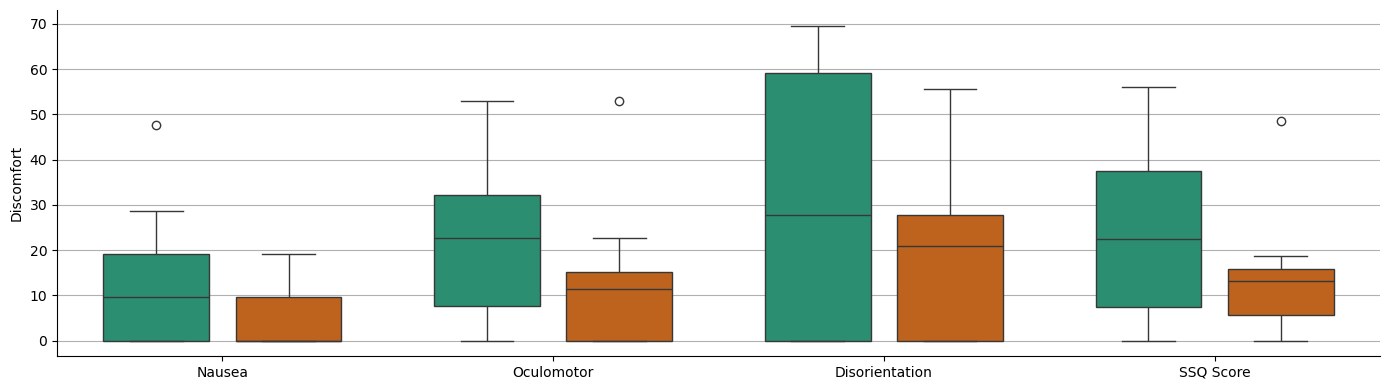

In [14]:
# Discomfort-related metrics

label = "Discomfort"
colnames = ["Nausea", "Oculomotor", "Disorientation", "SSQ Score"]

df_plot = data[data["variable"].isin(colnames)]

f, ax = plt.subplots(1, 1, figsize=(14, 4))

PALETTE_NAME = "Dark2"
with sns.color_palette(PALETTE_NAME):
    sns.boxplot(
        data=df_plot,
        x="variable",
        y="value",
        hue=COLNAME_INDEP_VAR,
        ax=ax,
        gap=.2
    )

    ax.set(xlabel="", ylabel=label)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("img-results2.pdf", dpi=200, bbox_inches="tight", pad_inches=0)
plt.savefig("img-results2.png", dpi=200, bbox_inches="tight", pad_inches=0)
plt.show()

## 5. Summary of Results

The boxplots compare the 2D Label and 3D Ghost conditions across task performance, usability, workload, and discomfort measures.

- **Task Completion Time:** The 3D Ghost condition had a lower median completion time (**121.72s**) than the 2D Label condition (**151.97s**), showing a **19.9% reduction**.
- **Usability:** The 2D Label condition had a slightly higher median SUS score (**85.0**) than the 3D Ghost condition (**82.5**). Both conditions were above the common SUS benchmark of **68**.
- **Workload:** The 3D Ghost condition showed slightly lower median NASA-TLX workload (**3.42**) than the 2D Label condition (**3.50**), showing a **2.4% reduction**.
- **Overall Discomfort:** The 3D Ghost condition had a lower median SSQ score (**15**) compared with the 2D Label condition (**27**), showing a **44.4% reduction**.
- **Nausea:** The 3D Ghost condition had a lower median nausea score (**0.00**) compared with the 2D Label condition (**9.54**).
- **Oculomotor Strain:** The 3D Ghost condition had a lower median score (**11.37**) than the 2D Label condition (**22.74**), showing a **50% reduction**.
- **Disorientation:** The 3D Ghost condition had a lower median score (**20.88**) than the 2D Label condition (**27.84**), showing a **25% reduction**.

Overall, the **3D Ghost** condition showed faster task completion and lower discomfort, while the **2D Label** condition showed slightly higher perceived usability.

## 6. Notes

This notebook focuses on descriptive statistics and visualization for the public portfolio version of the project. The full thesis/paper includes the statistical tests and complete interpretation.